In [1]:
## Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# supress the warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
X_train = pd.read_csv("X_train_final.csv")
X_test = pd.read_csv("X_test_final.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

### Base Model crestion with all features

In [4]:
# importing LinearRegression Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [7]:
## Predict output

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [8]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MAE :", train_mae)
print("Test MAE     :", test_mae)

print("Training RMSE:", train_rmse)
print("Test RMSE    :", test_rmse)

print("Training R²  :", train_r2)

Training MAE : 5.6260675877340605
Test MAE     : 5.576428160629665
Training RMSE: 7.072360272199116
Test RMSE    : 7.016529779180521
Training R²  : 0.7330137054746857


### Visualization of errors

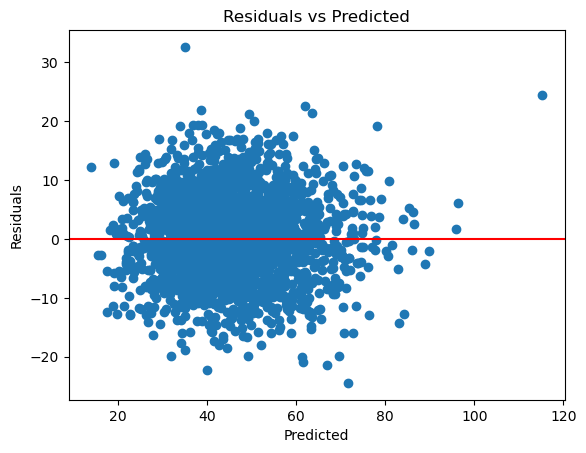

In [9]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

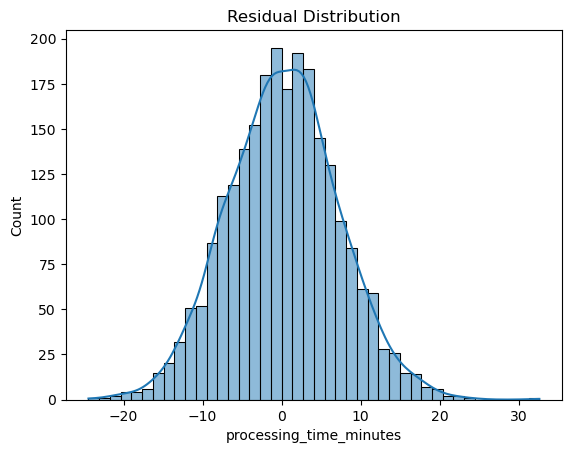

In [10]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

#### distribution of resudual look uniform and its not creating any patter

In [14]:
### Calculating VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Feature"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train.values, i)
              for i in range(X_train.shape[1])]

vif = vif.sort_values("VIF", ascending=False)
vif

,Feature,VIF
0,number_of_items,7.588528
2,number_of_skus,6.738675
1,total_quantity,3.478995
16,priority_Standard,3.416101
3,order_weight_kg,3.114183
4,picking_distance_m,2.735574
20,equipment_type_Trolley,2.543284
10,shift_Morning,1.919817
12,warehouse_zone_B,1.702949
13,warehouse_zone_C,1.641352


In [22]:
## Cross Validation score
from sklearn.model_selection import cross_val_score

model = LinearRegression()

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    )

#cv_mae = cv_scores

print("CV MAE for each fold:", cv_scores)
print("Mean CV MAE:", cv_scores.mean())
print("Std CV MAE:", cv_scores.std())
#print("Std CV MAE:", cv_scores.r2_score)

CV MAE for each fold: [0.73909523 0.72854874 0.73403207 0.73548858 0.71668827]
Mean CV MAE: 0.7307705759347316
Std CV MAE: 0.00781594199859139


In [29]:
cv_r2 = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="r2")

print(f'CV R2 for each fold:{cv_r2}')
print(f' Mean CV R2:{cv_r2.mean()}')
    
    

CV R2 for each fold:[0.73909523 0.72854874 0.73403207 0.73548858 0.71668827]
 Mean CV R2:0.7307705759347316


In [30]:
## Since we have multicollinearity, we will access Ridge,Lasso along with linear model

### Ridge with GridSearchCV

In [31]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="r2"
)
ridge_grid.fit(X_train, y_train)

print("Best Alpha:", ridge_grid.best_params_)
print("Best CV R²:", ridge_grid.best_score_)

Best Alpha: {'alpha': 10}
Best CV R²: 0.7307739255543215


### Lasso with GridSearchCV

In [33]:
from sklearn.linear_model import Lasso

lasso = Lasso()

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train, y_train)

print("Best Alpha:", lasso_grid.best_params_)
print("Best CV R²:", lasso_grid.best_score_)

Best Alpha: {'alpha': 0.001}
Best CV R²: 0.7307820216313512


#### Observation: Linear, Ridge,Lasso All three approaches provided same R2,Meaning lasso,Ridge are not improving performance significantly. 

In [34]:
## Baded on VIF, we will reduce feature= 'number_of_skus'
X_train_reduced = X_train.drop(columns=["number_of_skus"])

In [35]:
# Running the model again

model = LinearRegression()

cv_r2 = cross_val_score(
    model,
    X_train_reduced,
    y_train,
    cv=5,
    scoring="r2"
)

print("Mean CV R²:", cv_r2.mean())

Mean CV R²: 0.7307328667111604


In [ ]:
##CV R² stays approximately the same or improves, we have evidence that number_of_skus isn't adding much unique to train model.

In [37]:
### Keep number_of_skus removed and additionally remove number_of_items(high VIF):
X_train_reduced2 = X_train.drop(
    columns=["number_of_skus", "number_of_items"]
)

model = LinearRegression()

cv_r2 = cross_val_score(
    model,
    X_train_reduced2,
    y_train,
    cv=5,
    scoring="r2"
)

print("Mean CV R²:", cv_r2.mean())


Mean CV R²: 0.6994105767438912


In [ ]:
## interpretation:Removing "number_of_items" causes a substantial drop in CV R², from ~0.731 to ~0.699. Therefore, despite its VIF of 7.59, it contains useful predictive information.

In [38]:
X_train_reduced.head() # Removed "number_of_skus" Already

,number_of_items,total_quantity,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,temperature_c,shift_Morning,...,priority_Urgent,equipment_type_Forklift,equipment_type_Manual,equipment_type_Trolley,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0.294153,0.475492,0.955817,0.005023,-0.819665,-0.202508,-0.716163,2.475334,1.367106,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.613843,0.994473,-0.215634,-0.806213,-0.819665,-0.202508,-0.983004,0.230875,-1.502142,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.613843,-0.043489,-0.466957,-0.595689,0.529285,-0.202508,0.531965,-0.891354,1.039911,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.596818,-1.023785,-1.074205,-0.349893,-0.748667,-0.202508,0.351202,-0.891354,0.737885,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2.110144,2.493750,2.002764,1.935567,-0.322683,0.750004,0.290947,0.230875,-0.294038,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


#### removing highly corr features one by one "total_quantity","order_weight_kg" to see model performance

In [46]:
X_train_reduced3 = X_train_reduced.drop(columns=['total_quantity'])

model = LinearRegression()

cv_r2 = cross_val_score(
    model,
    X_train_reduced3,
    y_train,
    cv=5,
    scoring="r2"
)

print("Mean CV R²:", cv_r2.mean())


Mean CV R²: 0.6909932237739165


In [43]:
## R2 Reduced indicating that feature was providing unique information to the model and its useful feature

In [47]:
X_train_reduced4 = X_train_reduced.drop(columns=['order_weight_kg'])

model = LinearRegression()

cv_r2 = cross_val_score(
    model,
    X_train_reduced4,
    y_train,
    cv=5,
    scoring="r2"
)

print("Mean CV R²:", cv_r2.mean())


Mean CV R²: 0.7292378466875096


In [48]:
##  R2 Reduced from 0.7307328667111604 to 0.7292378466875096 indicating that feature was providing unique information to the model and its useful feature

### Trying to remove some visible less corr features to target one by one

#### fragile_items              
#### temperature_c             
#### picker_experience_months   
#### number_of_pickers        

In [50]:
# removing "temperature_c"

X_train_reduced5 = X_train_reduced.drop(columns=['temperature_c'])

In [51]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced5,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7308045008397921
Mean CV MAE: 5.647898251994273


In [ ]:
## R2 improved slightly when removed "temperature_c"

In [54]:
# removing "picker_experience_months"

X_train_reduced6 = X_train_reduced.drop(columns=['picker_experience_months'])

model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced6,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7269398952256164
Mean CV MAE: 5.68421585330416


In [55]:
# removing "fragile_items"

X_train_reduced7 = X_train_reduced.drop(columns=['fragile_items'])

model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced7,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7283142064195751
Mean CV MAE: 5.667537080963638


In [56]:
# removing "number_of_pickers"

X_train_reduced8 = X_train_reduced.drop(columns=['number_of_pickers'])

model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced8,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7151669275412397
Mean CV MAE: 5.814879519441019


In [57]:
X_train_reduced5.columns

Index(['number_of_items', 'total_quantity', 'order_weight_kg',
       'picking_distance_m', 'picker_experience_months', 'number_of_pickers',
       'warehouse_congestion', 'fragile_items', 'shift_Morning', 'shift_Night',
       'warehouse_zone_B', 'warehouse_zone_C', 'warehouse_zone_D',
       'warehouse_zone_E', 'priority_Standard', 'priority_Urgent',
       'equipment_type_Forklift', 'equipment_type_Manual',
       'equipment_type_Trolley', 'day_of_week_Monday', 'day_of_week_Saturday',
       'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday',
       'day_of_week_Wednesday'],
      dtype='object')

In [ ]:
#Removing days of week

In [58]:
# removing "day_of_week"

X_train_reduced9 = X_train_reduced5.drop(columns=['day_of_week_Monday','day_of_week_Saturday','day_of_week_Sunday','day_of_week_Thursday','day_of_week_Tuesday','day_of_week_Wednesday'])

model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced9,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7309631359419599
Mean CV MAE: 5.646848464903455


In [59]:
## Conclusion: No Meaningful Improvement in r2 by emoving the columns

In [63]:
# removing "shift_Morning', 'shift_Night'"

X_train_reduced10 = X_train_reduced5.drop(columns=['shift_Morning', 'shift_Night'])
model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced10,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7248262086432238
Mean CV MAE: 5.7157288155808725


In [ ]:
# R2 decresed ,hence feature was useful

In [62]:
# removing "warehouse_zone_B', 'warehouse_zone_C', 'warehouse_zone_D','warehouse_zone_E'"

X_train_reduced11 = X_train_reduced5.drop(columns=['warehouse_zone_B', 'warehouse_zone_C', 'warehouse_zone_D','warehouse_zone_E'])
model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced11,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7204559700824289
Mean CV MAE: 5.751188219994143


In [ ]:
# R2 decresed ,hence feature was useful

In [64]:
# removing "priority_Standard', 'priority_Urgent"

X_train_reduced12 = X_train_reduced5.drop(columns=['priority_Standard', 'priority_Urgent'])
model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced12,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.7299283144881394
Mean CV MAE: 5.66132256612482


In [ ]:
# R2 decresed ,hence feature was useful

In [65]:
# removing "equipment_type_Forklift', 'equipment_type_Manual','equipment_type_Trolley'"

X_train_reduced13 = X_train_reduced5.drop(columns=['equipment_type_Forklift','equipment_type_Manual','equipment_type_Trolley'])
model = LinearRegression()

scores = cross_validate(
    model,
    X_train_reduced13,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error"
    }
)

print("Mean CV R²:", scores["test_r2"].mean())
print("Mean CV MAE:", -scores["test_mae"].mean())

Mean CV R²: 0.696279784154722
Mean CV MAE: 6.008663381241853


In [66]:
# R2 decresed ,hence feature was useful

#### conclusion: removing features is not improving performance of model. Hence moving forward with model creation 
#### Features to be excluded :
(number_of_skus,
-temperature_c,
-day_of_week)

#### hence dataframe, "X_train_reduced9" is the final dataset

In [72]:
X_train_final= X_train_reduced9
print(X_train_final.shape)
X_train_final.head(1)

(9600, 19)


,number_of_items,total_quantity,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,shift_Morning,shift_Night,warehouse_zone_B,warehouse_zone_C,warehouse_zone_D,warehouse_zone_E,priority_Standard,priority_Urgent,equipment_type_Forklift,equipment_type_Manual,equipment_type_Trolley
0,0.294153,0.475492,0.955817,0.005023,-0.819665,-0.202508,-0.716163,2.475334,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [68]:
# making X_test ready with same columns as that of X_train_reduced9

X_test_final = X_test.drop(columns=['number_of_skus', 'temperature_c','day_of_week_Monday','day_of_week_Saturday','day_of_week_Sunday','day_of_week_Thursday','day_of_week_Tuesday','day_of_week_Wednesday'])

X_test_final.head()

,number_of_items,total_quantity,order_weight_kg,picking_distance_m,picker_experience_months,number_of_pickers,warehouse_congestion,fragile_items,shift_Morning,shift_Night,warehouse_zone_B,warehouse_zone_C,warehouse_zone_D,warehouse_zone_E,priority_Standard,priority_Urgent,equipment_type_Forklift,equipment_type_Manual,equipment_type_Trolley
0,-0.311178,0.014176,-0.120752,-0.235262,-0.464678,-0.202508,-0.965788,0.230875,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,-0.311178,0.071840,0.686443,0.212792,-0.890662,-1.155021,-0.457929,0.230875,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.202148,2.782072,3.188563,1.635762,-0.180688,-0.202508,-0.363244,-0.891354,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.596818,0.590821,1.103000,0.935299,-1.174652,0.750004,-1.594156,-0.891354,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.008512,-1.196779,-0.967752,0.478428,1.168262,1.702517,1.048432,2.475334,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [70]:
X_test_final.shape

(2400, 19)

#### After verifying Train,and test dataset having same columns proceeding with model building

In [74]:
# Training model

from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(X_train_final, y_train)

LinearRegression()

#### Final training metrics

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred = final_model.predict(X_train_final)     # predicting output on training data

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Training MAE :", train_mae)
print("Training RMSE:", train_rmse)
print("Training R²  :", train_r2)

Training MAE : 5.630267069813438
Training RMSE: 7.075690500011646
Training R²  : 0.7327622096558443


#### Final test metrics

In [76]:
y_test_pred = final_model.predict(X_test_final)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²  :", test_r2)

Test MAE : 5.573506376321657
Test RMSE: 7.01767868240992
Test R²  : 0.7367037296292387


#### Adjusted R²

In [77]:
n = X_test_final.shape[0]
p = X_test_final.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Test Adjusted R²:", adjusted_r2)

Test Adjusted R²: 0.7346017846136739


In [83]:
Results = pd.DataFrame({'Metric':['MAE', 'RMSE', 'R2'],
 'Training':[train_mae,train_rmse,train_r2],
 'Testing': [test_mae,test_rmse,test_r2]})

Results

,Metric,Training,Testing
0,MAE,5.630267,5.573506
1,RMSE,7.075691,7.017679
2,R2,0.732762,0.736704


#### Business Interpretation

The model explains approximately 73.7% of the variation in order processing time on previously unseen orders.

The MAE of 5.57 minutes means that, on average, the model's predicted processing time differs from the actual processing time by approximately 5–6 minutes.

The training and test results are very similar:

Training R²: 0.733
Test R²: 0.737
Training MAE: 5.63 min
Test MAE: 5.57 min

This indicates that the model has good generalization and no significant evidence of overfitting.

#### Key Conclusion

The developed Linear Regression model provides a reasonably accurate and stable baseline for predicting warehouse order processing time. It explains approximately 74% of the variation in processing time and produces predictions with an average error of about 5.6 minutes. The close alignment between training and test performance indicates that the model generalizes well to unseen orders

In [85]:
import joblib

joblib.dump(final_model, "linear_regression_model.pkl")

['linear_regression_model.pkl']